In [16]:
import pybamm # loads pybamm package
import os, sys
print(pybamm.__path__[0])
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy import integrate
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
import pickle # for saving simulations
import gzip
from scipy.signal import savgol_filter
from batfuns import *
import Siegel2022
%matplotlib widget

C:\Users\Vivian\University of Michigan Dropbox\Vivian Tran\from_box\Research\PyBaMM\PyBaMM2024\src\pybamm


## Load data

In [17]:
# load timeseries rpt data 
cell_name = "UMBL2022FEB_CELL152059"
file_path = "Z:/voltaiq_data/PROCESSED/UMBL2022FEB/" + cell_name + "/RPT.pkl.gz"

with gzip.open(file_path, "rb") as f:
    rpt_data_raw = pickle.load(f)
# df = df.sort_values(by=['Time [ms]'])
rpt_data_raw = rpt_data_raw.reset_index(drop=True)
# rpt_data_raw[['Time [ms]','RPT #','Test type', 'Protocol']]

FileNotFoundError: [Errno 2] No such file or directory: 'Z:/voltaiq_data/PROCESSED/UMBL2022FEB/UMBL2022FEB_CELL152059/RPT.pkl.gz'

In [ ]:
# Separate timeseries data by protocol
rpt_num = 2
rpt_data = rpt_data_raw[(rpt_data_raw['RPT #']==rpt_num)]
hppc = rpt_data[rpt_data['Protocol']=='HPPC'].iloc[0]  #HPPC
charge = rpt_data[rpt_data['Protocol']=='C/20 charge'].iloc[0] #C/20 Charge
discharge = rpt_data[rpt_data['Protocol']=='C/20 discharge'].iloc[0] #C/20 Discharge
# rpt_data_raw.loc[(rpt_data_raw['RPT #']==rpt_num), ['Time [ms]','RPT #','Test type', 'Protocol']]

Text(0.5, 0.98, 'UMBL2022FEB_CELL152059 RPT 2')

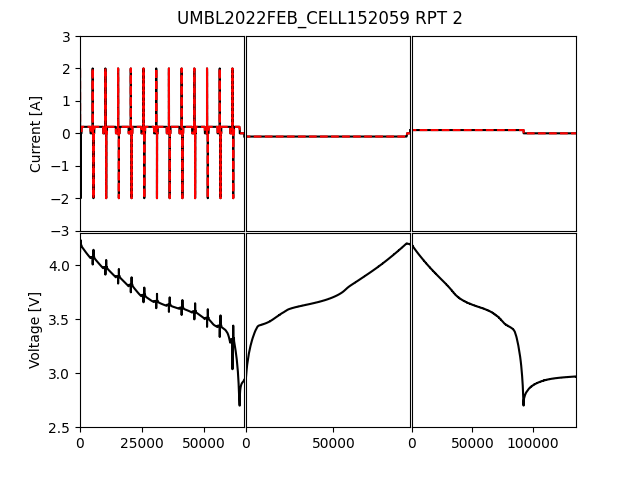

In [ ]:
# plot subcycle data 

fig,axs = plt.subplots(2,3)
plt.subplots_adjust(wspace = 0.01,hspace = 0.01, top = 0.925)
current_profiles=[]
# index, row in df.iterrows()
for s,(index,subcycle) in enumerate(rpt_data.iterrows()): #[hppc, charge, discharge]
    subcycle_data = subcycle.Data
    t_data = subcycle_data["Time [ms]"].to_numpy()/1000
    t_data=t_data-t_data[0]
    I_data = -subcycle_data['Current [A]'].to_numpy() # pybamm I>0 on discharge 
    # I_data = np.interp(t_sim, t_data, I_data, left=None, right=None, period=None)
    V_data= subcycle_data['Voltage [V]'].to_numpy()
    # V_data = np.interp(t_sim, t_data, V_data, left=None, right=None, period=None)

    # save current profile for running sim
    df0 = pd.DataFrame({'t':t_data, 'I':I_data})
    df = df0.drop_duplicates(subset='t', keep="first")
    current_profile = df.to_numpy() #.iloc[0:3200]
    current_profiles.append(current_profile)

    # plot current
    ax = axs[0,s]
    ax.plot(t_data,I_data,'k')
    ax.plot(current_profile[:,0],current_profile[:,1],'r--')
    ax.set_xlim(left=0, right = t_data[-1])
    ax.set_xlabel('Time [s]')
    ax.set_ylim([-3,3])
    if s ==0:
        ax.set_ylabel('Current [A]') 
    else: 
        ax.set_yticks([])
        ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_xticklabels([])

    #plot voltage
    ax = axs[1,s]
    ax.plot(t_data,V_data,'k')
    ax.set_xlim(left=0, right = t_data[-1])
    ax.set_ylim([2.5,4.3])
    if s ==0:
        ax.set_ylabel('Voltage [V]')
    else: 
        ax.set_yticks([])
        ax.set_yticklabels([])

    
fig.suptitle(f'{cell_name} RPT {rpt_num}')


## Simulation set up 

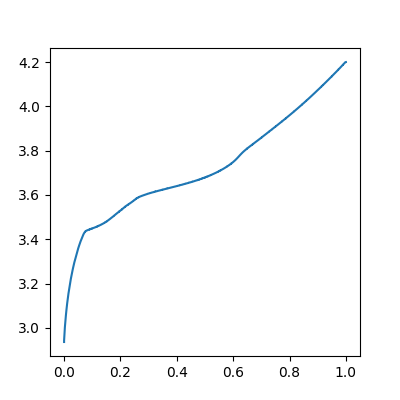

In [ ]:
I_ocv = charge.Data.loc[charge.Data['Current [A]']>0,'Current [A]']
t_ocv = charge.Data.loc[charge.Data['Current [A]']>0,'Time [ms]']/1000

SOC_ocv = 1+(integrate.cumulative_trapezoid(I_ocv[::-1],t_ocv[::-1]/3600,initial=0))/charge['Charge capacity [A.h]']
V_ocv = charge.Data.loc[charge.Data['Current [A]']>0,'Voltage [V]'][::-1]
fig,ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(SOC_ocv,V_ocv)
# ax.plot(t_ocv,SOC_ocv)

In [ ]:
# update model parameters 
model = pybamm.lithium_ion.SPMe() # for calculating parameters only
import Siegel2022
param_dict = Siegel2022.get_parameter_values()
parameter_values = pybamm.ParameterValues(param_dict)   
# parameters =  pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Tran2025)

parameter_values.update(
    {
        # "Maximum concentration in positive electrode [mol.m-3]": 31927.3,
        # "Maximum concentration in negative electrode [mol.m-3]": 29637,
        "Upper voltage cut-off [V]": 4.3, 
        "Lower voltage cut-off [V]": 2.5, 
        },
    check_already_exists=False,
)    
# Calculate initial SOC
I_ocv = charge.Data['Current [A]']
t_ocv = charge.Data.loc[I_ocv>0,'Time [ms]']/1000
SOC_ocv = (integrate.cumulative_trapezoid(I_ocv[I_ocv>0],t_ocv/3600,initial=0))/ (charge['Charge capacity [A.h]'])
V_ocv = charge.Data.loc[I_ocv>0,'Voltage [V]']
# I_ocv = charge.Data.loc[charge.Data['Current [A]']>0,'Current [A]']
# t_ocv = charge.Data.loc[charge.Data['Current [A]']>0,'Time [ms]']/1000
# SOC_ocv = 1+(integrate.cumulative_trapezoid(I_ocv[::-1],t_ocv[::-1]/3600,initial=0))/charge['Charge capacity [A.h]']
# V_ocv = charge.Data.loc[charge.Data['Current [A]']>0,'Voltage [V]'][::-1]
try: 
        Cn = charge.Cn
        Cp =charge.Cp
        x100 = charge.x100
        x0 = charge.x0
        y100=charge.y100
        y0=charge.y0
except: 
        # if any(np.isnan([Cn, Cp, x100, x0, y100,y0])):
        C_n_init = 4.06-1
        C_p_init =5.5-1
        x_init = 0.852
        y_init = 0.309
        Cn, Cp, x100, x0, y100, y0 = calculate_eSOH(C_n_init, C_p_init, x_init, y_init,model, parameter_values)
    
# set initial concentrations from SOC using OCV from C/20 discharge
parameter_sets=[]
for index,subcycle in rpt_data.iterrows():
    subcycle_data = subcycle.Data
    parameter_set = parameter_values.copy()
    V_0 = subcycle_data['Voltage [V]'].iloc[0]
    SOC_0 = np.interp(V_0, V_ocv, SOC_ocv) # V_ocv needs to be increasing
    x_init = (x100-x0)*SOC_0 + x0 
    y_init = (y100-y0)*SOC_0 + y0 

    param = model.param
    eps_n_init = parameter_set.evaluate(Cn*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
    eps_p_init = parameter_set.evaluate(Cp*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
    cs_n_init = parameter_set.evaluate(x_init* param.n.prim.c_max)
    cs_p_init = parameter_set.evaluate(y_init* param.p.prim.c_max)

    # Updating parameters for initialization
    parameter_set.update(
        {
            "Negative electrode active material volume fraction": eps_n_init,
            "Positive electrode active material volume fraction": eps_p_init,
            "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
            "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
            "Initial temperature [K]": 273.15+25,
            "Ambient temperature [K]": 273.15+25,
        },
        check_already_exists=False,
    )
    parameter_sets.append(parameter_set)
    print(f"SOC_0: {SOC_0}") 
print(f"x0: {x0}") 
print(f"x100: {x100}") 
print(f"y0: {y0}") 
print(f"y100: {y100}") 
print(f"Cn (usable): {(x100-x0)*Cn}") 
print(f"Cp (usable): {(y0-y100)*Cp}") 


SOC_0: 0.9891404347490963
SOC_0: 0.0
SOC_0: 0.9939899880852944
x0: 0.0053
x100: 0.8197
y0: 0.9661
y100: 0.3121
Cn (usable): 2.55900768
Cp (usable): 2.5590365999999998


In [9]:
# create experiments corresponding to rpt subcycle order
experiments=[]
for current_profile in current_profiles: #[hppc, charge, discharge]
    experiment = pybamm.Experiment(
        ["Rest for 1 second", 
        pybamm.step.current(current_profile),
        ]
        , period = "0.1 second"
        )
    experiments.append(experiment)

In [10]:
# simulate subcycles
models=[pybamm.lithium_ion.SPMe(name="SPMe"),pybamm.lithium_ion.SPM(name="SPM"),]
model_sols=[]
for model in models:
    sols=[]
    print(model.name)
    for i,(experiment, parameter_set) in enumerate(zip(experiments, parameter_sets)):
        print(i)
        sim = pybamm.Simulation(model, experiment=experiment,
                                parameter_values=parameter_set, 
                                solver=pybamm.CasadiSolver("safe"))
        sols.append(sim.solve()) #initial_soc=SOC_0
    model_sols.append(sols)

SPMe
0


2024-09-06 10:03:12.357 - [WARNING] callbacks.on_experiment_infeasible_event(252): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Step([[ 0.00000000e+00 -0.00000000e+00]
 [ 1.00000000e+00  1.99962401e+00]
 [ 2.00000000e+00  1.99962401e+00]
 ...
 [ 6.61850000e+04 -0.00000000e+00]
 [ 6.61950000e+04 -0.00000000e+00]
 [ 6.62010000e+04 -0.00000000e+00]], duration=66201.0, period=1.0, direction=Rest)'. The returned solution only contains up to step 1 of cycle 2. 


1


2024-09-06 10:03:14.163 - [WARNING] callbacks.on_experiment_infeasible_time(240): 

	Experiment is infeasible: default duration (93834.0 seconds) was reached during 'Step([[ 0.00000000e+00 -0.00000000e+00]
 [ 1.00000000e+00 -1.00002684e-01]
 [ 4.00000000e+00 -1.00002684e-01]
 ...
 [ 9.38150000e+04 -0.00000000e+00]
 [ 9.38250000e+04 -0.00000000e+00]
 [ 9.38340000e+04 -0.00000000e+00]], duration=93834.0, period=1.0, direction=Rest)'. The returned solution only contains up to step 1 of cycle 2. Please specify a duration in the step instructions.


2


...

2024-09-06 10:03:17.333 - [WARNING] callbacks.on_experiment_infeasible_event(252): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Step([[ 0.00000000e+00 -0.00000000e+00]
 [ 1.00000000e+00  1.99962401e+00]
 [ 2.00000000e+00  1.99962401e+00]
 ...
 [ 6.61850000e+04 -0.00000000e+00]
 [ 6.61950000e+04 -0.00000000e+00]
 [ 6.62010000e+04 -0.00000000e+00]], duration=66201.0, period=1.0, direction=Rest)'. The returned solution only contains up to step 1 of cycle 2. 


1


2024-09-06 10:03:18.445 - [WARNING] callbacks.on_experiment_infeasible_time(240): 

	Experiment is infeasible: default duration (93834.0 seconds) was reached during 'Step([[ 0.00000000e+00 -0.00000000e+00]
 [ 1.00000000e+00 -1.00002684e-01]
 [ 4.00000000e+00 -1.00002684e-01]
 ...
 [ 9.38150000e+04 -0.00000000e+00]
 [ 9.38250000e+04 -0.00000000e+00]
 [ 9.38340000e+04 -0.00000000e+00]], duration=93834.0, period=1.0, direction=Rest)'. The returned solution only contains up to step 1 of cycle 2. Please specify a duration in the step instructions.


2


2024-09-06 10:03:19.597 - [WARNING] callbacks.on_experiment_infeasible_event(252): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Step([[ 0.0000000e+00 -0.0000000e+00]
 [ 1.0000000e+01  9.9981837e-02]
 [ 2.0000000e+01  9.9981837e-02]
 ...
 [ 1.3532100e+05 -0.0000000e+00]
 [ 1.3533100e+05 -0.0000000e+00]
 [ 1.3533300e+05 -0.0000000e+00]], duration=135333.0, period=1.0, direction=Rest)'. The returned solution only contains up to step 1 of cycle 2. 


## Plot results

SPMe
SPM


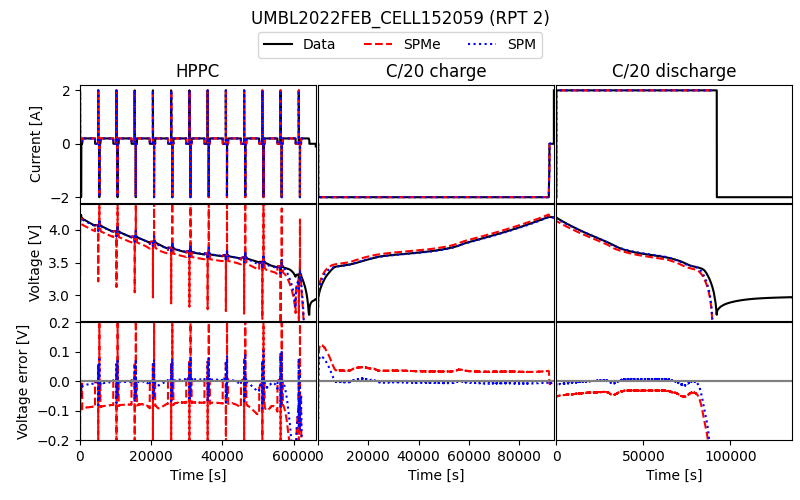

In [11]:
# plot data and sim results 
fig,axs = plt.subplots(3,len(sols),figsize=(8,5))
plt.subplots_adjust(hspace=0.01, wspace=0.01, top =0.83, left=0.1, right=0.99, bottom=0.12)
linestyles = ['r--', 'b:']
for m,(model,sols,ls) in enumerate(zip(models,model_sols,linestyles)):
    print(model.name)

    for s,(sol,(index,subcycle)) in enumerate(zip(sols, rpt_data.iterrows())):
       
        # data setup
        subcycle_data = subcycle.Data
        t_data = (subcycle_data['Time [ms]']-subcycle_data['Time [ms]'].iloc[0])/1000
        I_data = -subcycle_data['Current [A]']
        V_data = subcycle_data['Voltage [V]']
        t = sol["Time [s]"].entries
        I = sol["Current [A]"].entries
        Q = sol['Discharge capacity [A.h]'].entries
        Vt = sol["Terminal voltage [V]"].entries

        # plot current
        ax = axs[0,s]
        if m ==0:
            ax.plot(t_data,I_data,'k', label = 'Data')
        ax.plot(t,I,ls,  label = model.name)
        ax.set_xlim([0,t_data.iloc[-1]])
        if s ==0:
            ax.set_ylabel('Current [A]')
        else: 
            ax.set_yticks([])
            ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_title(subcycle.Protocol)

        ax = axs[1,s]
        e_V = Vt - np.interp(t,t_data, V_data)
        rmse_v = np.sqrt(np.mean(e_V**2))
        if m ==0:
            ax.plot(t_data,V_data,'k', label = 'Data')
        ax.plot(t,Vt,ls,  label = model.name + f' (RMSE = {round(rmse_v*1000)} mV)')
        ax.set_xlim([0,t_data.iloc[-1]])
        ax.set_ylim([2.6,4.4])
        if s ==0:
            ax.set_ylabel('Voltage [V]')
        else: 
            ax.set_yticks([])
            ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_xticklabels([])

        ax = axs[2,s]
        ax.plot(t,e_V,ls,  label = model.name)
        ax.plot([0,t_data.iloc[-1]], [0]*2, 'grey')
        ax.set_xlim([0,t_data.iloc[-1]])
        ax.set_ylim([-0.2,0.2])
        if s ==0:
            ax.set_ylabel('Voltage error [V]')
        else: 
            ax.set_yticks([])
            ax.set_yticklabels([])
        # ax.set_xticks([])
        # ax.set_xticklabels([])
        ax.set_xlabel('Time [s]')


# fig.tight_layout()
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center', ncol = len(models)+1, bbox_to_anchor=(0.5, .91), fancybox=True) #prop={'size': 10},  
fig.suptitle(cell_name + f' (RPT {rpt_num})')
plt.savefig('./figs/' + cell_name + '.jpg',format='jpg',dpi=300)

SPMe
SPM
SPMe
SPM


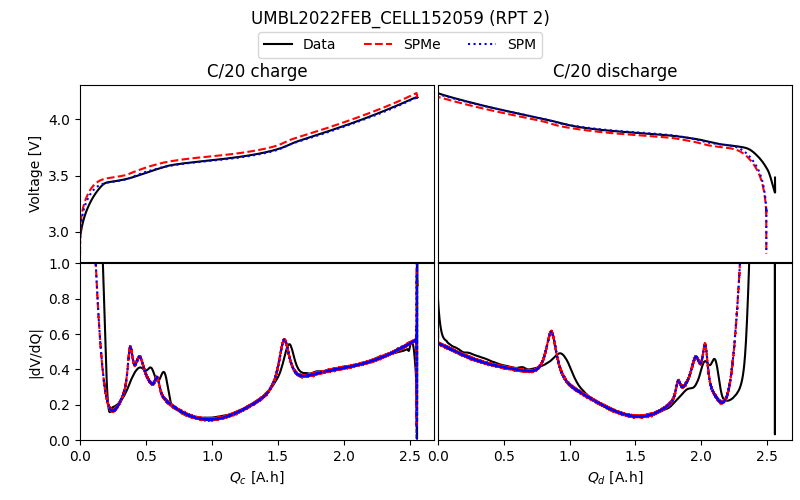

In [12]:
idx_C20 = [index for (index,subcycle) in rpt_data.iterrows() if "C/20" in subcycle['Protocol']]
idx_sims = [s for s,(index,subcycle) in enumerate(rpt_data.iterrows()) if "C/20" in subcycle['Protocol']]
C20s = rpt_data.loc[idx_C20]

fig,axs = plt.subplots(2,len(C20s),figsize=(8,5))
plt.subplots_adjust(hspace=0.01, wspace=0.01, top =0.83, left=0.1, right=0.99, bottom=0.12)
linestyles = ['r--', 'b:']

for s,(index,subcycle) in enumerate(C20s.iterrows()):
    for m,(sols, model, ls) in enumerate(zip(model_sols,models, linestyles)):
        print(model.name)

        # data setup
        subcycle_data = subcycle.Data
        t_data = (subcycle_data['Time [ms]']-subcycle_data['Time [ms]'].iloc[0])/1000
        I_data = -subcycle_data['Current [A]']
        V_data = subcycle_data['Voltage [V]']
        t = sols[idx_sims[s]]["Time [s]"].entries
        I = sols[idx_sims[s]]["Current [A]"].entries
        Q = sols[idx_sims[s]]['Discharge capacity [A.h]'].entries
        Vt = sols[idx_sims[s]]["Terminal voltage [V]"].entries

        # filter, calculate, and plot dQdV from data and sim results 
        if np.mean(I_data)<0: # charge
            Ah_sim=integrate.cumtrapz(-I,t,initial=0)/3600 
            Ah_data=integrate.cumtrapz(-I_data,t_data,initial=0)/3600
        else:# discharge
            Ah_sim=integrate.cumtrapz(I,t,initial=0)/3600 
            Ah_data=integrate.cumtrapz(I_data,t_data,initial=0)/3600 
            # Vt = -sol["Terminal voltage [V]"].entries
            # V_data = -subcycle_data['Voltage [V]']
            # Ah_sim=integrate.cumtrapz(-I,t,initial=charge['Charge capacity [A.h]'])/3600 + charge['Charge capacity [A.h]']
            # Ah_data=integrate.cumtrapz(-I_data,t_data,initial=charge['Charge capacity [A.h]'])/3600 + charge['Charge capacity [A.h]']


        # sgolay filter data and calculate dVdQ
        window_length=501
        polyorder=5
        Qf_d = savgol_filter(Ah_data,window_length,polyorder)
        dQ_d = savgol_filter(Ah_data,window_length,polyorder,1)
        Vf_d = savgol_filter(V_data,window_length,polyorder)
        dV_d = savgol_filter(V_data,window_length,polyorder,1)
        dVdQ_d = dV_d/dQ_d

        # sgolay filter sim results and calculate dVdQ
        window_length=51
        polyorder=5
        Qf_s = savgol_filter(Ah_sim,window_length,polyorder)
        dQ_s = savgol_filter(Ah_sim,window_length,polyorder,1)
        Vf_s = savgol_filter(Vt,window_length,polyorder)
        dV_s = savgol_filter(Vt,window_length,polyorder,1)
        dVdQ_s = dV_s/dQ_s

        # plot data vs sim dVdQ
        ax1 = axs[0,s]
        if m==0:
            ax1.plot(Qf_d,Vf_d,'k',label = 'Data')
        ax1.plot(Qf_s,Vf_s,ls,  label = model.name )
        ax1.set_xlim(left=0)
        ax1.set_title(subcycle.Protocol)
        if s ==0:
            ax1.set_ylabel('Voltage [V]')
        else: 
            ax1.set_yticks([])
            ax1.set_yticklabels([])
        ax1.set_xticks([])
        ax1.set_xticklabels([])

        ax2 = axs[1,s]
        if m==0:
            ax2.plot(Qf_d,abs(dVdQ_d),'k',label = 'Data')
        ax2.plot(Qf_s,abs(dVdQ_s),ls,  label = model.name)
        ax2.set_xlim(left=0)
        ax2.set_ylim([0,1])
        # ax2.set_ylim([-1,1])
        if np.mean(I_data)<0:
            ax2.set_xlabel('$Q_c$ [A.h]')
        else:
            ax2.set_xlabel('$Q_d$ [A.h]')
        if s ==0:
            ax2.set_ylabel('|dV/dQ|')
        else: 
            ax2.set_yticks([])
            ax2.set_yticklabels([])

handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center', ncol = len(models)+1, bbox_to_anchor=(0.5, .91), fancybox=True) #prop={'size': 10},  
fig.suptitle(cell_name + f' (RPT {rpt_num})')
plt.savefig('./figs/' + cell_name + '_dqdv.jpg',format='jpg',dpi=300)


# Archive

In [13]:
# param_dict = Siegel2022.get_parameter_values()
# parameters_js = param_dict #pybamm.ParameterValues(param_dict)  
# parameters =  pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)

# keys = parameters_js.keys()
# keys_mismatch = []
# keys_match = []
# keys_dne = []
# for key in keys: 
#     try:
#         if parameters[key] != parameters_js[key]:
#             if isinstance(parameters[key],(int, float)): # ignore functions and drive cycle
#                 keys_mismatch.append(key)
#         else:
#             keys_match.append(key)
#     except:
#         keys_dne.append(key)

# # df = pd.DataFrame([parameters[k for k in keys_mismatch], parameters_js[k for k in keys_mismatch]])
# # [parameters[k] for k in keys_mismatch]
# df = pd.DataFrame([{k: parameters[k] for k in keys_mismatch},
#                    {k: parameters_js[k] for k in keys_mismatch}]
#                    )
# # df["Name"] = ["Sravan's", "Jason's"]
# df.insert(0, "Name", ["Sravan's", "Jason's"])
# df

0.010092110856039761


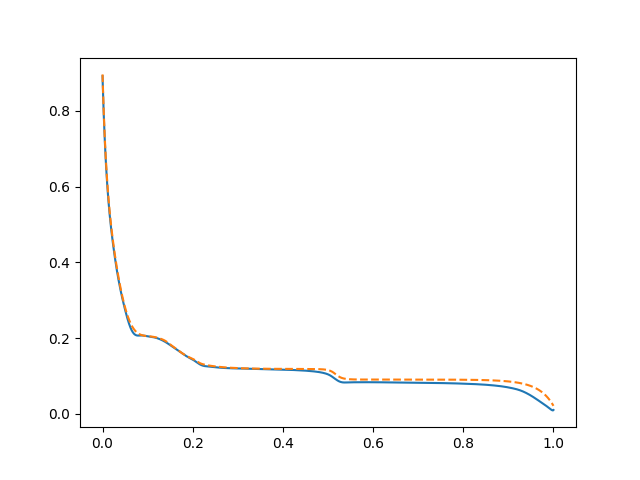

No such comm: 3d3cd20b07804228b57c9baffdd6e721


In [14]:
# plot Un fit
fn = r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm\input\parameters\lithium_ion\negative_electrodes\graphite_UMBL_Tran2025\graphite_ocp_Siegel.csv' 
Un_data = pd.read_csv(fn, comment='#', header = None, names = ["x", "Un"])
sto = Un_data.x + 0.002 #<-----EDIT


# var=[-3.54049607669295,0.00708244334002580,0.00774192469266890, 
# 4.26893363759502,-0.0164043013936254,-4.05401806281007, 
# 0.0426131798578846,-3.19444157210193,0.0503611972394406, 
# 0.170261138869476,0.147567301186300,0.0382504766072001, 
# 0.519446050169237,1.10619736534131,0.0145120887836752, 
# -0.0816693980616928,-0.0119716740325398,-0.00723858739498425, 
# -0.0877677643234304,0.0238786887373114,0.0452264234816890, 
# -0.00713413913218840]

p_eq=[-3.54049607669295,0.00708244334002580,0.00774192469266890, 
    4.26893363759502,-0.0164043013936254,-4.05401806281007, 
    0.0426131798578846,-3.19444157210193]#var[0:8]
a_eq=[0.0503611972394406, 0.170261138869476,0.147567301186300,
    0.0382504766072001, 0.519446050169237,1.10619736534131,
    0.0145120887836752,]#var[8:15]
b_eq = [-0.0816693980616928,-0.0119716740325398,-0.00723858739498425, 
    -0.0877677643234304,0.0238786887373114,0.0452264234816890, 
    -0.00713413913218840]#var[15:]
u_eq2=p_eq[-1]+p_eq[-2]*np.exp((sto-a_eq[-1])/b_eq[-1])
for i in range(6):
    u_eq2 += p_eq[i]*np.tanh((sto-a_eq[i])/b_eq[i])

# var = [-2.74740857138957,0.00443109156371119,0.0140962302368559, 
#     3.10348817994589,-0.0128948359572101,-4.36083705035769, 
#     0.0643328570911640,-3.88703879262989,0.0631828141079049, 
#     0.213012646348329,0.174731100372283,0.0577291579271751, 
#     0.518982409471130,1.21588542781399,0.0150389780167150, 
#     -0.0584524226380269,-0.00702394962468186,-0.0342305292048576, 
#     -0.0619846453717142,0.0123530018211038,0.0873816814557679, 
#     -0.00843321991754559]
p_eq=[-2.74740857138957,0.00443109156371119,0.0140962302368559, 
    3.10348817994589,-0.0128948359572101,-4.36083705035769, 
    0.0643328570911640,-3.88703879262989]#var[0:8]
a_eq=[0.0631828141079049,
    0.213012646348329,0.174731100372283,0.0577291579271751, 
    0.518982409471130,1.21588542781399,0.0150389780167150]#var[8:15]
b_eq = [-0.0584524226380269,-0.00702394962468186,-0.0342305292048576, 
    -0.0619846453717142,0.0123530018211038,0.0873816814557679, 
    -0.00843321991754559] #var[15:]
u_eq1=p_eq[-1]+p_eq[-2]*np.exp((sto-a_eq[-1])/b_eq[-1])
for i in range(6):
    u_eq1 += p_eq[i]*np.tanh((sto-a_eq[i])/b_eq[i])

Un_fit = u_eq1*0.7 + u_eq2*0.3 #(u_eq1 + u_eq2)/2#-0.01 #<-----EDIT


sto2 = sto # 0.02
Un_fit_peyman = (
    0.063
    + 0.8 * np.exp(-75 * (sto2 + 0.001))
    - 0.0120 * np.tanh((sto2 - 0.127) / 0.016)
    - 0.0118 * np.tanh((sto2 - 0.155) / 0.016)
    - 0.0035 * np.tanh((sto2 - 0.220) / 0.020)
    - 0.0095 * np.tanh((sto2 - 0.190) / 0.013)
    - 0.0145 * np.tanh((sto2 - 0.490) / 0.020)
    - 0.0800 * np.tanh((sto2 - 1.030) / 0.055)
)
# Un_fit_peyman = Siegel2022.graphite_ocp_PeymanMPM(sto)

# calculate rmse (0.0167 NOMINAL)
rmse_Un = np.sqrt(np.mean((Un_fit-Un_data.Un)**2))
# rmse_Un_peyman = np.sqrt(np.mean((Un_fit-Un_fit_peyman)**2))

print(rmse_Un)
# print(rmse_Un_peyman)

# plot
plt.close('all')
plt.plot(Un_data.x, Un_data.Un)
plt.plot(Un_data.x, Un_fit, '--')
# plt.plot(Un_data.x, Un_fit_peyman, ':')

# plt.plot(Up_data.y, Up_fit2)
plt.show()

0.010355647169182273


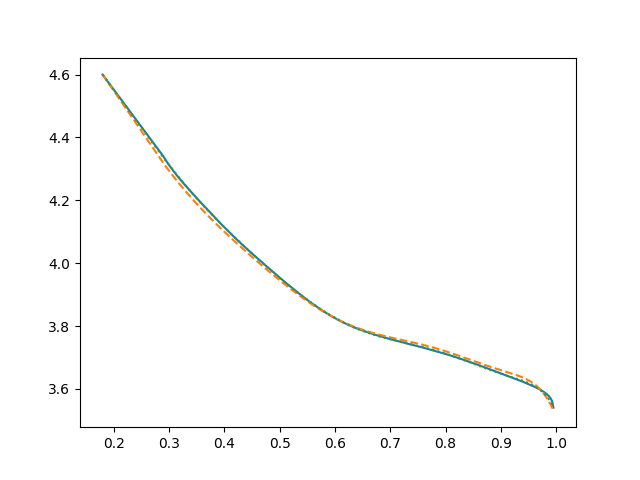

No such comm: baec79543e5f48b88f886ae306f7f935


No such comm: 9a27437c2fee4a2c99c5c086634d06c7


In [ ]:
# plot Up fit
fn = r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm\input\parameters\lithium_ion\positive_electrodes\NMC_UMBL_Tran2025\NMC_ocp_Siegel.csv' 
Up_data = pd.read_csv(fn, comment='#', header = None, names = ["y", "Up"]).iloc[0:-1]


p1 = -2253.9364
p2 = 10756.6071
p3 = -21755.8183
p4 = 24277.2504
p5 = -16299.5659
p6 = 6728.9153
p7 = -1670.2785
p8 = 233.2321
p9 = -18.3223*0.9979 #<-----EDIT
p10 = 5.3936*0.999 #<-----EDIT

sto = Up_data.y
Up_fit = p1*sto**9 + p2*sto**8 + p3*sto**7 + p4*sto**6 + p5*sto**5 + p6*sto**4 + p7*sto**3 + p8*sto**2 + p9*sto + p10
Up_fit_jason = (
    -2708.586858 * (sto ** 9) +13443.432624 * (sto ** 8) 
    -28538.487067 * (sto ** 7) +33871.076514 * (sto ** 6) 
    -24665.620934 * (sto ** 5) +11381.032457 * (sto ** 4) 
    -3313.239062 * (sto ** 3) +586.285653 * (sto ** 2) 
    -59.774094 * (sto ** 1) +7.408439 
    )
# calculate rmse (0.0215 NOMINAL)
rmse_Up = np.sqrt(np.mean((Up_fit-Up_data.Up)**2))
print(rmse_Up)

plt.close('all')
plt.plot(Up_data.y, Up_data.Up)
plt.plot(Up_data.y, Up_fit,'--')
plt.plot(Up_data.y, Up_fit_jason,':')

# plt.plot(Up_data.y, Up_fit2)
plt.show()

4.19395542
1.0


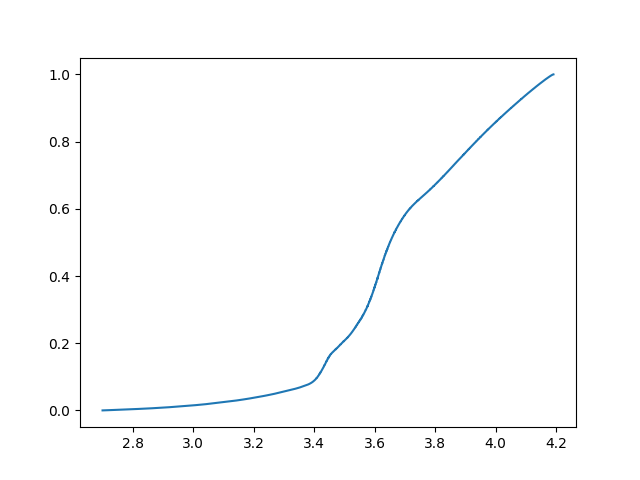

In [ ]:
I_d = abs(discharge.Data['Current [A]'])
t_d = discharge.Data.loc[I_d>0,'Time [ms]']/1000
V_ocv = discharge.Data.loc[I_d>0,'Voltage [V]']
SOC_ocv = (discharge['Discharge capacity [A.h]']-integrate.cumtrapz(I_d[I_d>0],t_d/3600,initial=0))/discharge['Discharge capacity [A.h]']
V_0 = subcycle_data['Voltage [V]'].iloc[0]
SOC_0 = np.interp(4.2, V_ocv[::-1], SOC_ocv[::-1]) # V_ocv needs to be increasing
print(V_0)
print(SOC_0)
plt.close('all')
plt.plot(V_ocv,SOC_ocv)
plt.show()

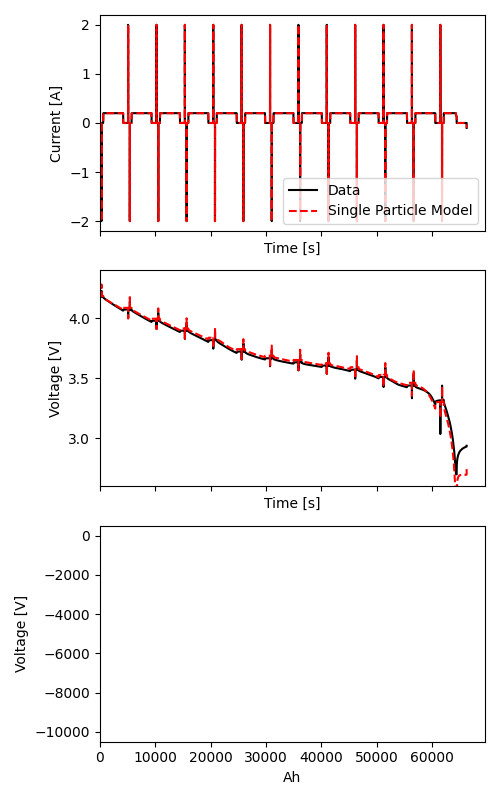

In [ ]:
# plot data and sim results 
t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
Q = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries
if np.mean(I_data)<0:
    Ah_data=integrate.cumtrapz(-I_data,t_data,initial=0)/3600
    Ah_sim=integrate.cumtrapz(-I,t,initial=0)/3600
else:
    Ah_data=integrate.cumtrapz(I_data,t_data,initial=0)/3600
    Ah_sim=integrate.cumtrapz(I,t,initial=0)/3600


fig,axs = plt.subplots(3,1,figsize=(5,8))#,sharex=True)
axs = axs.flatten()
ax = axs[0]
ax.plot(t_data,I_data,'k', label = 'Data')
ax.plot(t,I,'r--',  label = model.name)
ax.legend()
ax.set_xlim(left=0)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Current [A]')


ax = axs[1]
ax.plot(t_data,V_data,'k')
ax.plot(t,Vt,'r--')
ax.set_xlim(left=0)
ax.set_ylim([2.6,4.4])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')


ax = axs[2]
ax.plot(Ah_data,V_data,'k')
ax.plot(Ah_sim,Vt,'r--')
ax.set_xlim(left=0)
ax.set_xlabel('Ah')
ax.set_ylabel('Voltage [V]')
fig.tight_layout()

